<font size=3;>
<p style="text-align: right;"> Lab Solution --- <b>NOT FOR DISTRIBUTION!</b> </p>
</font>

# Lab I: A/B Causality Test

## Setup

In [1]:
# Import some useful functions
from numpy import *
from numpy.random import *
from datascience import *
from statsmodels.formula.api import *

# Define some useful functions
def correlation(array_1, array_2):
    return corrcoef(array_1, array_2).item(1)

# Customize look of graphics
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['figure.dpi'] = 60
%matplotlib inline

# Force display of all values 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Hide some unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")
import numpy
numpy.int = numpy.int_

## Website Click-Throughs

### Business Decision

A software and services company wants to drive its website visitors from the splash page to commerce pages that describe and offer additional for-fee services.  The regular splash page includes graphics, text, and a link to the commerce pages.  At the start of each month, a new splash page design is introduced on a trial basis for a week, which includes certain new graphics, new text, and a link to the commerce pages.  When a visitor goes to the company's website, that visitor is presented with either the regular splash page or the new splash page, selected by machine randomly with equal probabilities.  After a week, if the new splash page seems more effective, then it replaces the regular splash page for the remainder of the month.

Assume that you are the Vice President of Marketing.  Does Design A cause more visitors to go to the commerce pages than Design B does?  Should you revise the splash page to present Design A instead of Design B to all visitors?

### Data

Retrieve the website splash page click-through dataset of all visitors during the trial period (Splash_Page_1.csv).  
Each observation represents one visitor interaction: 
* customer_id is a unique identifier for the visitor
* design is A or B, and indicates which design was presented
* clickthru is 0 or 1, where 0 indicates that the visitor did not go to the commerce pages, and 1 indicates that the visitor did

Show the first few observations.

In [4]:
data = Table().read_table('Splash_Page_1.csv')
data

customer_id,design,clickthru
1,A,1
2,B,0
3,A,1
4,B,1
5,B,1
6,B,1
7,B,0
8,A,1
9,A,1
10,A,0


### Analysis

#### Actual Outcome

Explore what actually happened during the trial period.

For each design, show the number of visitors that were presented that design during the trial period.

In [5]:
data.group('design')

design,count
A,504
B,510


For each design, show the probability that a visitor went to the commerce pages during the trial period.

In [6]:
trial_prob = data.select('design','clickthru').group('design', mean)
trial_prob

design,clickthru mean
A,0.521825
B,0.470588


Show the difference between the probabilities.

In [7]:
trial_diff = trial_prob.column('clickthru mean').item(0) - trial_prob.column('clickthru mean').item(1)
trial_diff

0.05123716153127922

#### Hypothesized Outcome

Note that visitors were presented with one of two possible designs by chance.  Perhaps these results are due to chance, too.  In other words, perhaps some visitors would have gone to the commerce pages regardless of which design was presented.  Similarly, perhaps some vistors would have not gone regardless.

To test for this possible chance occurrence, hypothesize that the designs had no effect on the visitors' actions, and then look for evidence that suggests that your hypothesis is unlikely.

Under the assumption that the designs have no effect, you could have scrambled which visitors were presented with which designs, and the visitors' actions would have been the same.

Construct an array of design choices (A or B), in the same proportion as in the actual trial period,
but randomly ordered.  _To do this, use the choice() function with argument replace=False._

In [9]:
seed(1)
scramble = choice(data.column('design'), data.num_rows, replace=False)
scramble

array(['A', 'A', 'B', ..., 'A', 'A', 'A'],
      dtype='<U1')

Construct a table like the one you just did showing the assumed clickthru values, except
replace the design column with the one new array (for scrambled design choices).

In [10]:
data_hypo = data.with_column('design', scramble)
data_hypo

customer_id,design,clickthru
1,A,1
2,A,0
3,B,1
4,B,1
5,A,1
6,B,1
7,A,0
8,A,1
9,B,1
10,A,0


For each design, show the probability that a visitor would have gone to the commerce pages during the trial period
(one probability for Design A and another probability for Design B), assuming the scrambled design choices.

In [11]:
prob = data_hypo.select('design','clickthru').group('design', mean)
prob

design,clickthru mean
A,0.511905
B,0.480392


Show the difference between the probabilities.

In [12]:
diff = prob.column('clickthru mean').item(0) - prob.column('clickthru mean').item(1)
diff

0.03151260504201675

Explore the range of results you could have seen if the design choice had no effect on visitors' actions.

Get 1000 different scrambles of design choices.  For each scramble, calculate what would have been
the probabilities of a vistor going to the commerce pages (one probability for Design A and another
probability for Design B).  Calculate and show a histogram of all 1000 probability differences (30 bins, range -0.1 to 0.1).

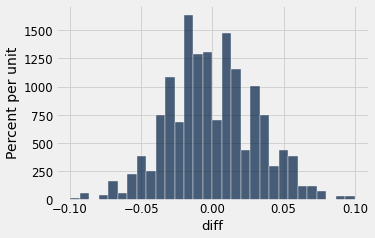

In [13]:
seed(1)

dist_array = make_array()

for i in arange(1000):
    scramble_i = choice(data.column('design'), data.num_rows, replace=False)
    data_hypo_i = data.with_column('design', scramble_i)
    prob_i = data_hypo_i.select('design','clickthru').group('design', mean)
    diff_i = prob_i.column('clickthru mean').item(0) - prob_i.column('clickthru mean').item(1)
    dist_array = append(dist_array, diff_i)

dist = Table().with_column('diff', dist_array)
dist.hist(bins=30, range=make_array(-0.1, 0.1))

Calculate and show the probability that the trial probability difference would be >= 0.0512
if the design has no effect on visitors' actions. (This is the p-value.)
Also show the histogram of probability differences with the area corresponding to the probability highlighted.

0.065

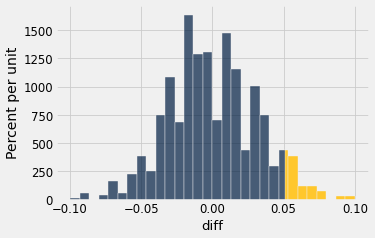

In [14]:
p_value = dist.where('diff', are.above_or_equal_to(trial_diff)).num_rows / dist.num_rows
p_value

dist.hist(bins=30, range=make_array(-0.1, 0.1), left_end=trial_diff, right_end=0.1)

Calculate and show the lower bound of the probability difference corresponding to the highest 5%
of results, based on what you could have seen if the design choice has no effect on visitors' actions.
(This is the critical value @ significance level 0.05.)
Also show the histogram of probability differences with the area corresponding to the significance level highlighted.

0.055182072829131679

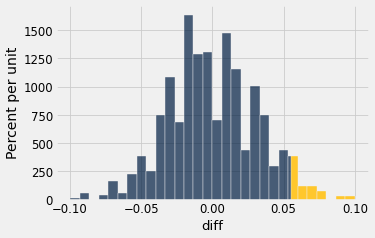

In [15]:
cv = percentile(95, dist.column('diff'))
cv

dist.hist(bins=30, range=make_array(-0.1, 0.1), left_end=cv, right_end=0.1)

Calculate and show that you should conclude that the hypothesis is correct (i.e., conclude that the design makes no difference), at significance level 0.05.

In [16]:
p_value > 0.05
trial_diff < cv

True

True

<p style="text-align:left; font-size:10px;">
Copyright (c) Huntsinger Associates, LLC
<span style="float:right;">
Document revised October 20, 2023
</span>
</p>